In [1]:
%pip -q install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: C:\Users\arnav\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def imshow_rgb(img_bgr, title=None):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


template shape: (219, 1557, 3)
input shape: (784, 2400, 3)


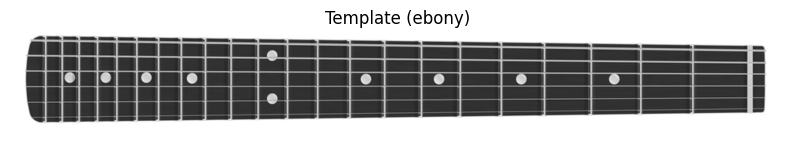

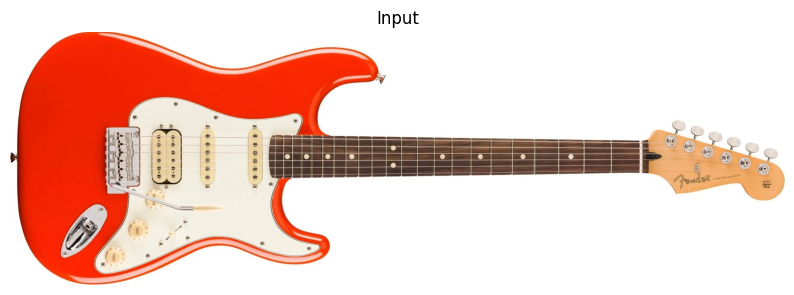

In [3]:
TEMPLATE_PATH = "ebony.png"
INPUT_PATH    = "input.png"

template = cv2.imread(TEMPLATE_PATH, cv2.IMREAD_COLOR)
inp      = cv2.imread(INPUT_PATH, cv2.IMREAD_COLOR)

if template is None:
    raise FileNotFoundError(f"Could not read template at: {TEMPLATE_PATH}")
if inp is None:
    raise FileNotFoundError(f"Could not read input at: {INPUT_PATH}")

print("template shape:", template.shape)
print("input shape:", inp.shape)

imshow_rgb(template, "Template (ebony)")
imshow_rgb(inp, "Input")


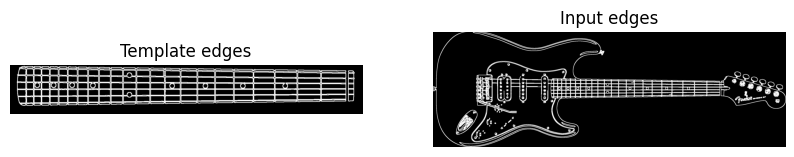

In [4]:
def preprocess_for_matching(img_bgr, blur_ksize=5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if blur_ksize and blur_ksize > 1:
        gray = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    edges = cv2.Canny(gray, 50, 150)
    edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)
    return edges

temp_proc = preprocess_for_matching(template)
inp_proc  = preprocess_for_matching(inp)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(temp_proc, cmap="gray"); plt.axis("off"); plt.title("Template edges")
plt.subplot(1,2,2); plt.imshow(inp_proc, cmap="gray");  plt.axis("off"); plt.title("Input edges")
plt.show()


In [5]:
def multiscale_match_template(
    img_proc,
    templ_proc,
    scales=None,
    method=cv2.TM_CCOEFF_NORMED,
    min_template_size=(40, 40),
):
    if scales is None:
        scales = np.linspace(0.35, 2.25, 40)

    best = {
        "score": -1.0,
        "scale": None,
        "top_left": None,
        "wh": None,
        "result_shape": None,
    }

    th, tw = templ_proc.shape[:2]
    for s in scales:
        new_w = int(round(tw * s))
        new_h = int(round(th * s))
        if new_w < min_template_size[0] or new_h < min_template_size[1]:
            continue
        if new_w >= img_proc.shape[1] or new_h >= img_proc.shape[0]:
            continue

        templ_resized = cv2.resize(templ_proc, (new_w, new_h), interpolation=cv2.INTER_AREA)
        res = cv2.matchTemplate(img_proc, templ_resized, method)

        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        score = max_val if method in (cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED,
                                      cv2.TM_CCORR, cv2.TM_CCORR_NORMED) else -min_val
        loc   = max_loc if method in (cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED,
                                      cv2.TM_CCORR, cv2.TM_CCORR_NORMED) else min_loc

        if score > best["score"]:
            best.update(
                score=score,
                scale=float(s),
                top_left=loc,
                wh=(new_w, new_h),
                result_shape=res.shape,
            )

    if best["top_left"] is None:
        raise RuntimeError("No valid scales produced a match. Check image paths/sizes.")
    return best

best = multiscale_match_template(inp_proc, temp_proc)
best


{'score': 0.5753427743911743,
 'scale': 0.7397435897435898,
 'top_left': (882, 317),
 'wh': (1152, 162),
 'result_shape': (623, 1249)}

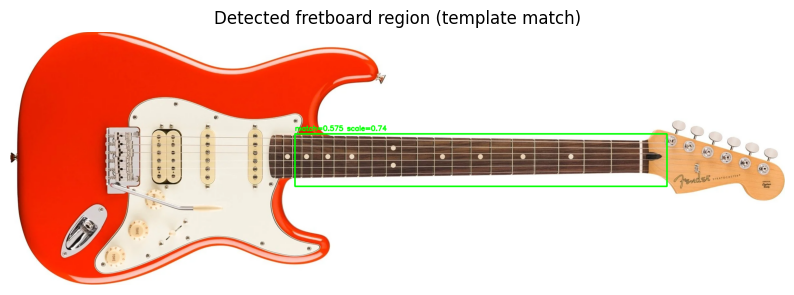

Best match score: 0.5753
Box: x=882, y=317, w=1152, h=162


In [6]:
x, y = best["top_left"]
w, h = best["wh"]
score = best["score"]

out = inp.copy()
cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.putText(out, f"match={score:.3f} scale={best['scale']:.2f}", (x, max(25, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

imshow_rgb(out, "Detected fretboard region (template match)")
print(f"Best match score: {score:.4f}")
print(f"Box: x={x}, y={y}, w={w}, h={h}")


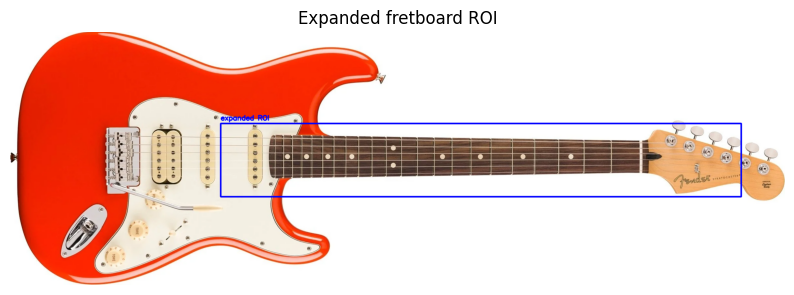

Expanded ROI: x0=652, y0=285, x1=2264, y1=511


In [7]:
def expand_box(x, y, w, h, img_w, img_h, pad_frac=0.15):
    pad_x = int(round(w * pad_frac))
    pad_y = int(round(h * pad_frac))
    x0 = max(0, x - pad_x)
    y0 = max(0, y - pad_y)
    x1 = min(img_w - 1, x + w + pad_x)
    y1 = min(img_h - 1, y + h + pad_y)
    return x0, y0, x1, y1

H, W = inp.shape[:2]
x0, y0, x1, y1 = expand_box(x, y, w, h, W, H, pad_frac=0.20)

out2 = inp.copy()
cv2.rectangle(out2, (x0, y0), (x1, y1), (255, 0, 0), 3)
cv2.putText(out2, "expanded ROI", (x0, max(25, y0 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)

imshow_rgb(out2, "Expanded fretboard ROI")
print(f"Expanded ROI: x0={x0}, y0={y0}, x1={x1}, y1={y1}")


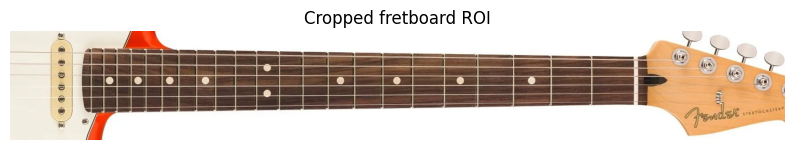

In [8]:
roi = inp[y0:y1, x0:x1].copy()
imshow_rgb(roi, "Cropped fretboard ROI")